# Cost of Mid-Tier Customer Neglect Using RFM Analysis
## Team 7 - Business Analytics Capstone

In [46]:
# All imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime as dt
from IPython.display import display

pd.set_option('display.max_columns', None)

PALETTE = {
    'L':  '#4E6B8C',
    'M1': '#6BAA75',
    'M2': '#E8A838',
    'M3': '#D46A6A',
    'H':  '#7B5EA7',
}
SEGMENT_ORDER = ['L', 'M1', 'M2', 'M3', 'H']

## 1. Data Loading

In [47]:
# Load UCI Online Retail dataset
df = pd.read_csv('../data/Online_Retail.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [48]:
# Inspect data info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


## 2. Data Cleaning

In [49]:
# Drop missing CustomerIDs, filter invalid quantities/prices, create TotalPrice and YearMonth
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


## 3. Exploratory Data Analysis (EDA)

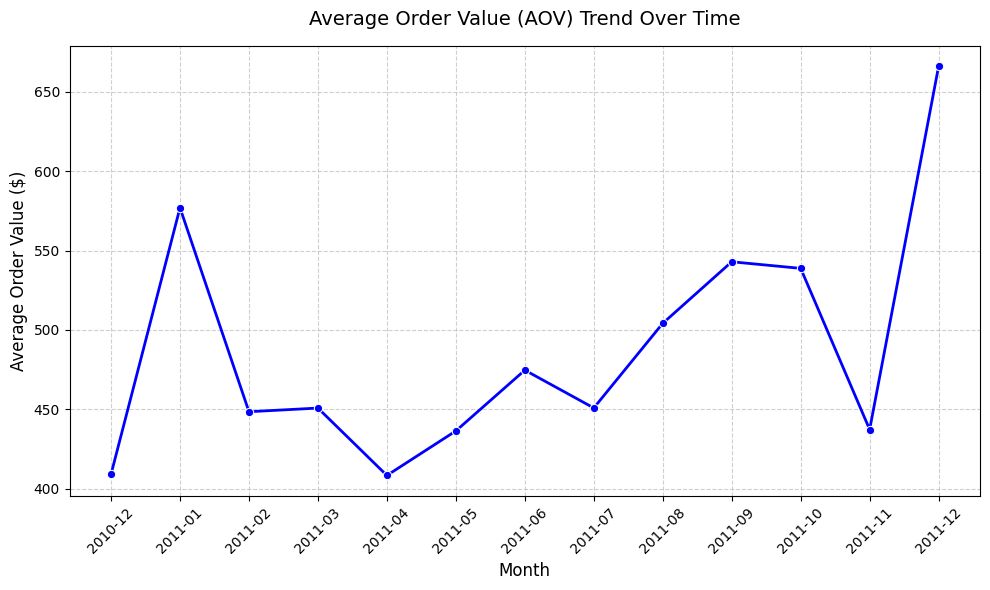

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month'] = df['InvoiceDate'].dt.to_period('M')

invoice_totals = df.groupby(['InvoiceNo', 'Month'])['TotalPrice'].sum().reset_index()

aov_trend = invoice_totals.groupby('Month')['TotalPrice'].mean().reset_index()
aov_trend['Month'] = aov_trend['Month'].astype(str) 

plt.figure(figsize=(10, 6))
sns.lineplot(data=aov_trend, x='Month', y='TotalPrice', marker='o', color='b', linewidth=2)

plt.title('Average Order Value (AOV) Trend Over Time', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Order Value ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

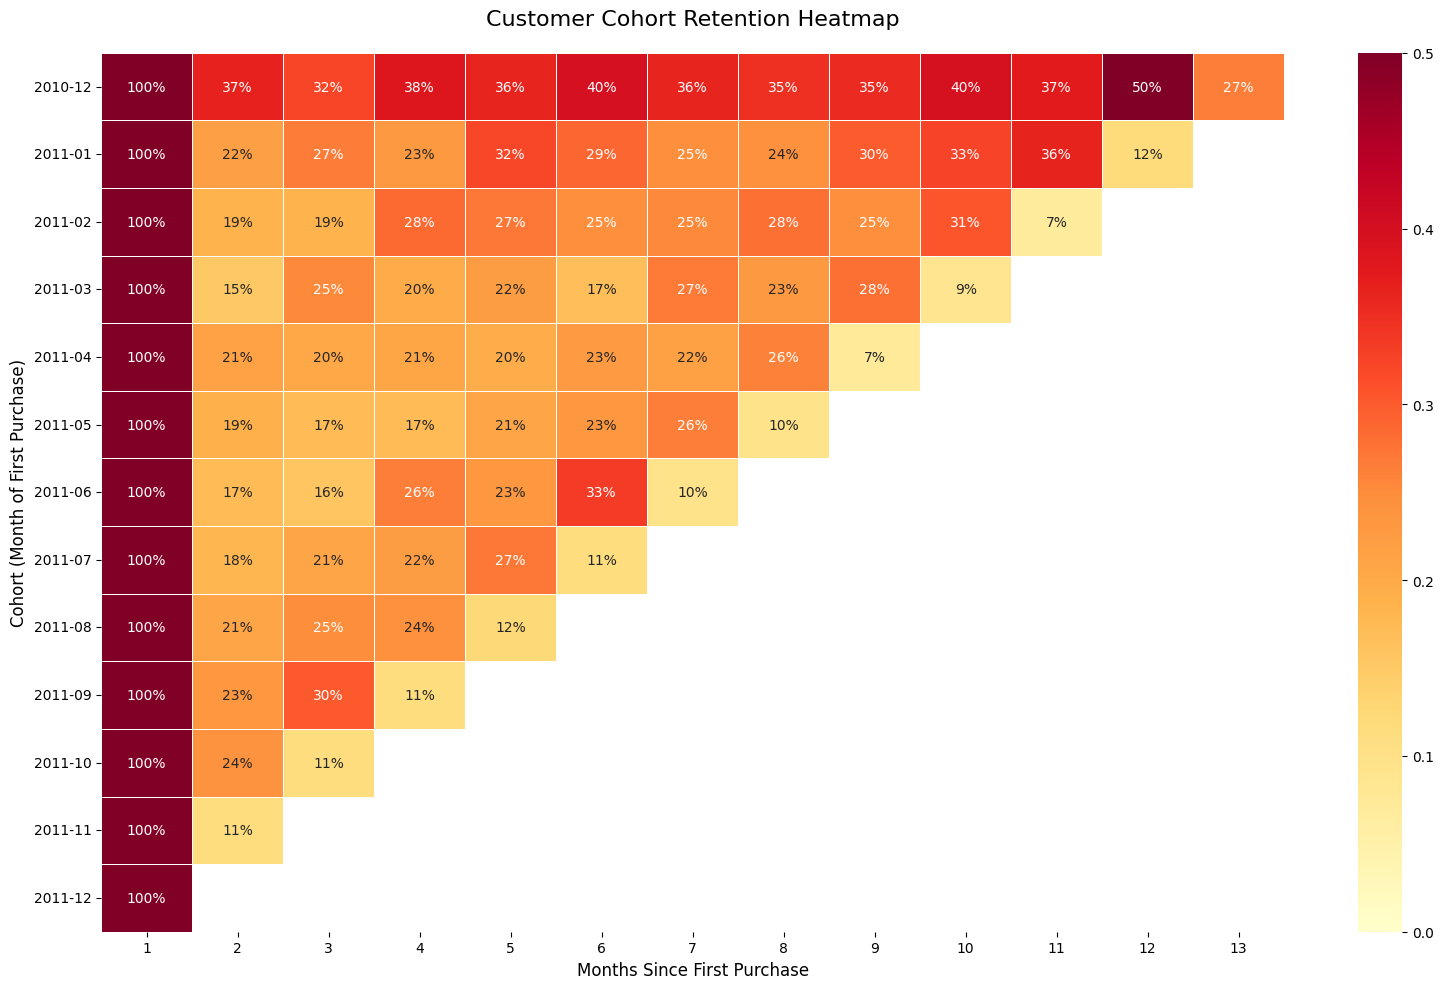

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = df.dropna(subset=['CustomerID']).copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df, 'InvoiceMonth')
cohort_year, cohort_month = get_date_int(df, 'CohortMonth')

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

df['CohortIndex'] = years_diff * 12 + months_diff + 1 

cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

retention.index = retention.index.strftime('%Y-%m')

# 8. Plot the Heatmap
plt.figure(figsize=(16, 10))
plt.title('Customer Cohort Retention Heatmap', fontsize=16, pad=20)

sns.heatmap(
    retention, 
    annot=True,         
    fmt='.0%',           
    vmin=0.0,         
    vmax=0.5,        
    cmap='YlOrRd',     
    linewidths=0.5
)

plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort (Month of First Purchase)', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. RFM Feature Engineering

In [52]:
# Compute RFM metrics per customer relative to max invoice date
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [53]:
# Assign R/F/M scores (1-3) and sum to RFM_Score
rfm['R_score'] = pd.qcut(rfm['Recency'], 3, labels=[3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 3, labels=[1, 2, 3])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 3, labels=[1, 2, 3])
rfm['RFM_Score'] = rfm[['R_score', 'F_score', 'M_score']].astype(int).sum(axis=1)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,3,5
12347.0,2,7,4310.00,3,3,3,9
12348.0,75,4,1797.24,2,2,3,7
12349.0,19,1,1757.55,3,1,3,7
12350.0,310,1,334.40,1,1,1,3


## 5. Customer Segmentation (3-Tier)

In [54]:
# Assign 3-tier segment and display distribution
def segment_customer(score):
    if score <= 4:
        return 'Bottom Tier'
    elif score <= 6:
        return 'Mid Tier'
    else:
        return 'Top Tier'

rfm['Customer_Segment'] = rfm['RFM_Score'].apply(segment_customer)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Customer_Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,3,5,Mid Tier
12347.0,2,7,4310.00,3,3,3,9,Top Tier
12348.0,75,4,1797.24,2,2,3,7,Top Tier
12349.0,19,1,1757.55,3,1,3,7,Top Tier
12350.0,310,1,334.40,1,1,1,3,Bottom Tier


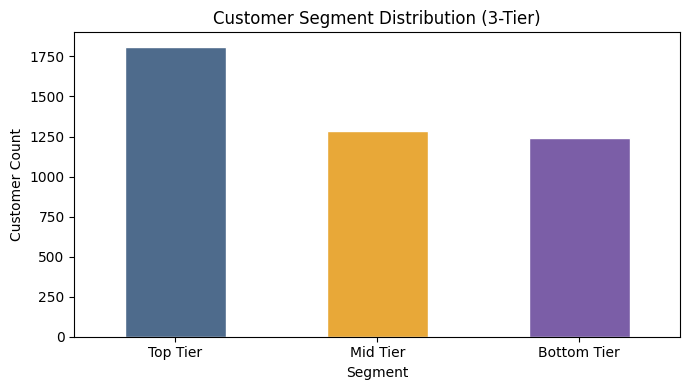

In [55]:
# Bar chart of 3-tier segment distribution
segment_counts = rfm['Customer_Segment'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
segment_counts.plot(kind='bar', ax=ax, color=['#4E6B8C', '#E8A838', '#7B5EA7'], edgecolor='white')
ax.set_title('Customer Segment Distribution (3-Tier)')
ax.set_xlabel('Segment')
ax.set_ylabel('Customer Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 6. Extended Segmentation (L, M1, M2, M3, H)

In [56]:
# Create 5-level segmentation using quantiles on RFM Score
rfm['Extended_Segment'] = pd.qcut(rfm['RFM_Score'], 5, labels=['L', 'M1', 'M2', 'M3', 'H'])
rfm['Extended_Segment'].value_counts()

Extended_Segment
L     1242
M2    1131
H      723
M1     684
M3     558
Name: count, dtype: int64

In [57]:
# Merge 5-tier segment back to transaction-level data
df_segmented = df.merge(rfm[['Extended_Segment']], left_on='CustomerID', right_index=True)
df_segmented.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth,Month,InvoiceMonth,CohortMonth,CohortIndex,Extended_Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12,2010-12-01,2010-12-01,1,M2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,2010-12-01,2010-12-01,1,M2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12,2010-12-01,2010-12-01,1,M2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,2010-12-01,2010-12-01,1,M2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,2010-12-01,2010-12-01,1,M2


In [58]:
# Export for Tableau
df_segmented.to_csv('tableau_transactions_segmented.csv', index=False)
rfm.to_csv('tableau_rfm_customers.csv', index=True)

## 7. Monthly Revenue by Customer Segment (Stacked Bar Chart)

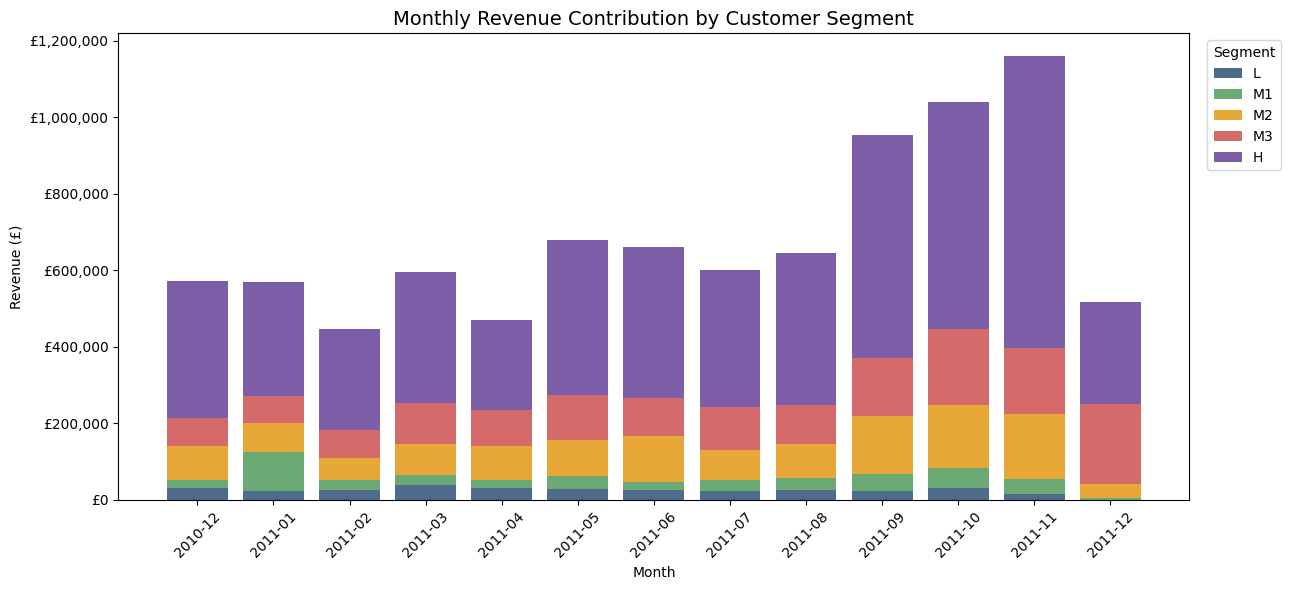

In [59]:
# Compute and plot monthly revenue stacked by segment
monthly_segment_revenue = (
    df_segmented
    .groupby(['YearMonth', 'Extended_Segment'], observed=False)['TotalPrice']
    .sum()
    .unstack()
    .reindex(columns=SEGMENT_ORDER, fill_value=0)
)
monthly_segment_revenue.index = monthly_segment_revenue.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(monthly_segment_revenue))
for seg in SEGMENT_ORDER:
    ax.bar(
        monthly_segment_revenue.index,
        monthly_segment_revenue[seg],
        bottom=bottom,
        label=seg,
        color=PALETTE[seg]
    )
    bottom += monthly_segment_revenue[seg].values

ax.set_title('Monthly Revenue Contribution by Customer Segment', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

### Dec 2010 → Jan 2011

**What actually happened (from the chart):**
- Counter-intuitively, **M1 revenue grew in January 2011** while December was expected to be the stronger month. The green (M1) band is visibly larger in Jan-2011 than in Dec-2010.
- H (purple) pulled back slightly, yet total revenue stayed approximately flat at ~£575K both months — meaning M1 buyers organically stepped up to fill the gap.

**Why it likely happened:**
- The dataset is dominated by wholesale buyers. Many M1-tier wholesalers placed their *post-Christmas replenishment* orders in January rather than December, since December stock was already locked in.
- For M1 specifically — lower-frequency, moderate spenders — January represents a "fresh budget" moment at the start of the calendar year.

**What could have been done (and applied to Feb 2011):**
- Since M1 responded well in January *without* any outreach, the key question is: **what did M1 customers buy?** Identifying the top product lines purchased by M1 in January and sending a targeted replenishment or adjacent-product offer in late January would have primed M1 for February.
- Example action: "You ordered [product X] in January — here's a complementary bundle available for February delivery."

**Missed opportunity cost (estimate):**
- M1 dropped back in February 2011 (chart shows the green band contracting). If January's M1 uplift had been nurtured into February via proactive outreach, an estimated **£10,000–£20,000** of M1 February revenue could have been retained or extended.

### Jan 2011 → Feb 2011

**What actually happened (from the chart):**
- February 2011 shows the **sharpest dip in the first half of the year** — total drops from ~£575K to ~£445K (~22% decline).
- **M1 retreats sharply** — the green band shrinks significantly compared to January's elevated level.
- M2 (amber) and M3 (salmon) also contract, but M2 in particular is noticeably thinner in February.
- H (purple) also drops, confirming this was a broad market slowdown, not segment-specific.

**Why it likely happened:**
- January's mid-tier uplift (especially M1) was driven by post-Christmas replenishment — a one-time event. Once that need was satisfied, M1 customers had no inherent reason to return in February.
- February is historically a low-demand period for the UK wholesale home goods market post-New Year.

**What could have been done:**
- January's M1 purchase data holds the key: identify the **categories that drove M1's January spike** and launch a "February restocking" campaign mid-January targeting those same categories.
- For M2 (which also dipped), a Valentine's Day-linked bundle (home gifts, decorative items) in early February would have given a demand signal to an otherwise quiet market.

**Missed opportunity cost (estimate):**
- M1 + M2 February shortfall vs. January levels represents roughly **£50,000–£70,000** in deferred/lost mid-tier revenue for this single monthly drop.

### Feb 2011 → Mar 2011

**What actually happened (from the chart):**
- March 2011 marks a **strong recovery** — total climbs from ~£445K back to ~£600K (+35%).
-**M2 (amber) visibly leads the recovery** — the amber band is noticeably larger in March than in February.
- **M3 (salmon) also grows** meaningfully. H (purple) resumes its climb.
- **M1 (green) barely participates** — the green band remains thin in March, almost unchanged from February.

**Why it likely happened:**
- M2 and M3 customers are more frequent buyers who react to the natural spring buying cycle (home décor restocking, Mother's Day range). M1, being lower-frequency, lacks the same seasonal trigger without a push.
- H-tier wholesale buyers are simply executing their pre-planned Q2 procurement.

**What could have been done:**
- M2's organic March recovery suggests these customers responded to *something* — new product arrivals, seasonal relevance, or spring awareness. **Replicate that trigger for M1:** send M1 a "Spring New In" catalogue in late February so they enter March already primed.
- Since M1 didn't join the recovery, February was the window to convert M1's January purchase behavior into a March repeat. A targeted "you bought X in Jan — the spring version is available" email in mid-February would have activated M1.

**Missed opportunity cost (estimate):**
- If M1 had grown proportionally with M2 in March, the additional M1 revenue would represent approximately **£15,000–£25,000** in the month.

### Mar 2011 → Apr 2011

**What actually happened (from the chart):**
- April 2011 is a **second dip** — total drops from ~£600K to ~£465K (~22% decline).
- **M2 and M3 both contract** noticeably from their March levels. The amber and salmon bands visibly narrow.
- **H (purple) is also lower**, indicating this is a broad market contraction, not isolated to mid-tier.
- M1 remains thin — it never fully recovered from Feb, so its April contraction is less dramatic in absolute terms.

**Why it likely happened:**
- March's spending spurt exhausted near-term demand for M2/M3. These customers placed their spring orders in March and don't need to reorder in April.
- Easter 2011 (late April) may have disrupted ordering cycles — wholesale buyers who typically order mid-month may have delayed to May.

**What could have been done:**
- **Look at which M3 customers stayed active in April** (the chart shows M3 contracted but didn't disappear): those are the "always-on" buyers in M3. Understanding what they bought in April would reveal the **recession-proof product lines** that drive loyalty.
- Use those M3 "always-on" products as the basis for an M1/M2 Easter promotion — framing April as a gifting opportunity (Easter hampers, spring home gifts).

**Missed opportunity cost (estimate):**
- M2+M3 combined April shortfall vs. March peak represents **£60,000–£90,000** in mid-tier revenue decline. Even recovering 20% via targeted outreach = ~£12,000–£18,000 additional.

### Apr 2011 → May 2011

**What actually happened (from the chart):**
- May 2011 delivers the **strongest mid-year revenue month** — total jumps from ~£465K to ~£675K (+45%).
- **M2 (amber) registers the biggest absolute mid-tier gain** — the amber band is clearly the most prominent mid-tier colour in May, significantly wider than in April.
- **M3 also recovers strongly.** H (purple) maintains its size.
- M1 (green) also shows modest improvement, but lags well behind M2's resurgence.

**Why it likely happened:**
- May is the start of the UK summer buying season for home goods and gifts. M2 customers — moderate-to-frequent buyers — are season-activated: they respond predictably to new product ranges and pre-summer merchandising.
- The post-Easter resumption of normal buying also contributes: the disruption from April cleared and pent-up demand released in May.

**What could have been done:**
- **M2's strong May natural recovery is predictable year-over-year.** The business could lever this pattern by giving M1 customers the *same seasonal triggers* that M2 responds to — in early April, not May. A "Summer preview for early birds" campaign sent to M1 in April, with incentives for May delivery, would pull M1's May order forward.
- Identifying the specific product categories driving May's M2 surge and pre-positioning stock alerts for M1 in late April.

**Missed opportunity cost (estimate):**
- If M1 had grown proportionally to M2 in May, the incremental M1 uplift would be approximately **£20,000–£30,000** in additional revenue.

### May 2011 → Jun 2011

**What actually happened (from the chart):**
- June 2011 sees a **moderate pullback** — total dips from ~£675K to ~£655K (only ~3% decline, relatively mild).
- **M2 and M3 hold up reasonably well** — both bands are slightly thinner but visible. The mid-tier didn't collapse the way it did in Feb or April.
- M1 (green) continues to lag — a thin band across both months; no meaningful improvement or worsening.
- H (purple) is slightly smaller.

**Why it likely happened:**
- May's surge was driven by seasonal activation. June is a natural consolidation — buyers placed spring orders in May and pause before summer-specific demands.
- The mild June dip (vs. the sharper Feb/April drops) suggests M2/M3 customers have more inherent buying cadence in summer than M1.

**What could have been done:**
- **The fact that M2 and M3 held in June while M1 did not participate** is the key signal. Examine what M2/M3 customers bought in June — those are the "summer replenishment" categories.
- Use May's M1 purchase history to send a follow-up "How's your summer stock looking?" email to M1 in late May — specifically referencing their March/May purchases and offering complementary products for June.

**Missed opportunity cost (estimate):**
- The gap is relatively mild this month. Closing M1's participation gap vs. M2 in June represents approximately **£8,000–£12,000** in unrealized M1 revenue.

### Jun 2011 → Jul 2011

**What actually happened (from the chart):**
- July 2011 brings a **further softening** — total falls from ~£655K to ~£600K (~8% decline).
- **M2 and M3 both contract** from June. The amber and salmon bands are thinner in July.
- Notably, **M3 (salmon) shows greater resilience** than M2 — the salmon band contracts less proportionally than amber, suggesting M3 customers maintain higher buying frequency even in the slow summer months.
- M1 remains flat and thin. H shows a slight decline.

**Why it likely happened:**
- Summer holiday season reduces wholesale ordering activity — buyers are distracted or have already placed their summer orders. M3's relative resilience suggests higher-engagement customers continue buying even without prompts.

**What could have been done:**
- **M3's relative resilience in July is a diagnostic signal.** What distinguishes M3 buyers in July from M1/M2? It's likely purchase frequency — M3 customers have habitual buying patterns. Study July's M3 product mix and leverage it to design an M1 "summer habit formation" campaign: a small, easy-to-execute July order that keeps M1 engaged during the slow months.
- For M2 (which contracted more than M3), a "mid-summer restock" promotion tied to their top 3 purchased categories would help prevent complete disengagement.

**Missed opportunity cost (estimate):**
- If M1 had matched M3's relative resilience in July, the additional M1 revenue represents approximately **£10,000–£15,000** in retained revenue.

### Jul 2011 → Aug 2011

**What actually happened (from the chart):**
- August 2011 shows a **marginal uptick** — total edges from ~£600K to ~£645K (+7.5%).
- **M3 (salmon) visibly ticks upward** — the salmon band is noticeably thicker in August vs. July, suggesting M3 customers are among the first to respond to the approaching Q4 season.
- M2 (amber) is roughly stable. M1 (green) remains flat and disengaged.
- H (purple) also begins a mild uptick.

**Why it likely happened:**
- M3 customers — more engaged, higher RFM scores — are the "early movers" for Q4 planning. They begin ordering in August for September/October delivery. This aligns with wholesale dynamics where advanced lead times are common.
- M1 customers, being less engaged and lower-frequency, have not yet received signals to mobilize for Q4.

**What could have been done:**
- **M3's August re-engagement is a predictable leading indicator.** Business action: in late July, segment M1 customers who bought in May (the last strong month) and send them an "August early-bird Q4 catalogue" — framing August ordering as access to priority stock before the September rush.
- This would have two effects: activating M1 in September AND capturing some M1 revenue in August itself (currently a wasted month for M1).

**Missed opportunity cost (estimate):**
- Capturing even 30% of the M1 revenue gap between August and September's upcoming surge amounts to approximately **£15,000–£25,000** of revenue pulled forward into August.

### Aug 2011 → Sep 2011

**What actually happened (from the chart):**
- September 2011 is a **watershed month** — the single biggest month-on-month jump in the dataset. Total surges from ~£645K to ~£960K (+49%).
- **M2 (amber) nearly doubles in absolute size** — the amber band is dramatically wider in September, making it the dominant visual change on the chart.
- **M3 (salmon) also surges strongly.** H (purple) makes a large upward move.
- **M1 (green) also participates** — the green band is visible and wider than in August, suggesting even lower-engagement customers activated.

**Why it likely happened:**
- This is the **Q4 wholesale procurement wave**. Wholesale buyers across all segments place their Christmas stock orders in September for October–December delivery. The magnitude of September's jump is entirely consistent with a wholesale-heavy customer base (well documented in the UCI Online Retail dataset).
- M2 leading the charge confirms that mid-frequency buyers are driven by this seasonal wholesale trigger more than by ad-hoc promotions.

**What could have been done:**
- **This September surge is predictable year-over-year.** The missed opportunity is in August: an "Pre-Q4 ordering window — guarantee your Christmas stock" campaign sent to ALL mid-tier customers in mid-August would have pulled some of September's revenue into August and maximized mid-tier participation in the Q4 wave.
- For M1 specifically: a direct outreach in August showing their historical top-products with a "pre-order for September delivery" nudge would ensure M1 doesn't lag M2/M3 in September's surge.

**Missed opportunity cost (estimate):**
- M1 growth in September, while real, still lagged M2 proportionally. Closing that gap would represent approximately **£30,000–£50,000** in additional mid-tier revenue across M1 and M2 in September alone.

### Sep 2011 → Oct 2011

**What actually happened (from the chart):**
- October 2011 continues the upward trajectory — total climbs from ~£960K to ~£1,045K (+9%).
- **M2 (amber) remains very strong** — the amber band stays at its elevated September level or grows slightly, confirming sustained wholesale buying.
- **M3 (salmon) also holds at high levels.** The combined mid-tier (M1+M2+M3) stack is visibly large.
- **M1 (green) shows modest growth** but does not match the proportional strength of M2/M3. The green band is present but thin relative to the amber and salmon bands.

**Why it likely happened:**
- October is the second wave of Christmas procurement. Buyers who committed in September continue ordering; new buyers who missed September's window also enter.
- M2 customers have high buying momentum from September's trigger — they continue engaging. M1 customers, lacking the habitual buying frequency of M2, don't sustain the October momentum as well.

**What could have been done:**
- **M1's relative underperformance vs. M2 in October is the key signal.** In September — when M1 was already activated — send M1 a follow-up "October continuation" offer: "You ordered X in September — secure your top-up order for November delivery before stock runs out."
- This converts September's M1 activation into a sustained October commitment, narrowing the M1/M2 gap.

**Missed opportunity cost (estimate):**
- If M1's October growth rate matched M2's, the incremental M1 revenue represents approximately **£25,000–£40,000** in additional October revenue.

### Oct 2011 → Nov 2011

**What actually happened (from the chart):**
- November 2011 is the **absolute peak of the dataset** — total hits ~£1,160K, the highest bar on the chart.
- **M3 (salmon) reaches its highest absolute level** — the salmon band is at its widest in the entire dataset, visually very prominent in November.
- **M2 (amber) also peaks.** The combined mid-tier bands (M1+M2+M3) stack to approximately £400K+ in November — the highest mid-tier total across all 13 months.
- **M1 (green) also improves** — wider green band than October — but still significantly smaller than M2/M3.

**Why it likely happened:**
- November is the final Christmas procurement window for wholesale buyers. M3 customers — mid-to-high frequency buyers — place their last large orders. M2 follows. H buyers have been placing orders all through Q4.
- The M3 peak is notable: these customers are close to H-tier in behaviour and respond strongly to the seasonal urgency of November.

**What could have been done:**
- **M3's November peak creates a retention opportunity for December and beyond:** these customers are at their highest engagement level. In November, trigger a "loyalty reward for next order" for M3 — to reduce the dramatic December drop-off (seen next month).
- For M1's missed November upside: October's M1 activation was the window. A "You've already ordered for Christmas — here's what your customers will be reordering in January: lock in now" email in late October would have generated additional M1 November volume.

**Missed opportunity cost (estimate):**
- The M1 gap vs. M2 in November — the highest-revenue month of the year — represents approximately **£30,000–£50,000** in unrealized M1 revenue at peak season.

### Nov 2011 → Dec 2011

**What actually happened (from the chart):**
- December 2011 shows the **sharpest single-month collapse** in the dataset — total plummets from ~£1,160K to ~£520K (-55%).
- **All mid-tier segments retreat dramatically.** The M2 (amber), M3 (salmon), and M1 (green) bands all narrow sharply. The entire mid-tier stack visually collapses compared to November.
- H (purple) also drops significantly, though it remains proportionally large.
- Note: December 2011 is a **partial month** (dataset ends mid-December), so the absolute drop partly reflects data truncation.

**Why it likely happened:**
- Christmas procurement for wholesale is completed in October–November. December itself is rarely when wholesale buyers place new orders — they're selling their stock, not buying more.
- The partial-month data amplifies the apparent decline: if December were a full month, total revenue would likely be higher (but still well below November's peak).
- M1 customers — already the least-engaged segment — have essentially zero urgency to buy in December once their Q4 orders are placed.

**What could have been done:**
- **November's M3 peak is the setup for December retention:** send M3 customers a "January replenishment preview" in the first week of December — framing it as early access to post-Christmas restocking. This captures December M3 revenue AND sets up a strong January 2012.
- For M1: remember that January 2011 showed a natural M1 uplift (as seen at the start of this analysis). Set up a **January 2012 pre-order campaign targeted at M1 in December** — "Start 2012 strong — January stock available now." This mirrors what caused the January 2011 M1 natural spike, but proactively.

**Missed opportunity cost (estimate):**
- Projecting a "full December" at even 60% of November's pace suggests approximately **£175,000–£200,000** of December revenue would have been achievable. Partial data captures only ~£520K of a potential ~£700K month — a gap of **£180,000**, with mid-tier responsible for an estimated **£40,000–£60,000** of that shortfall.

## 8. Advanced EDA Visualizations

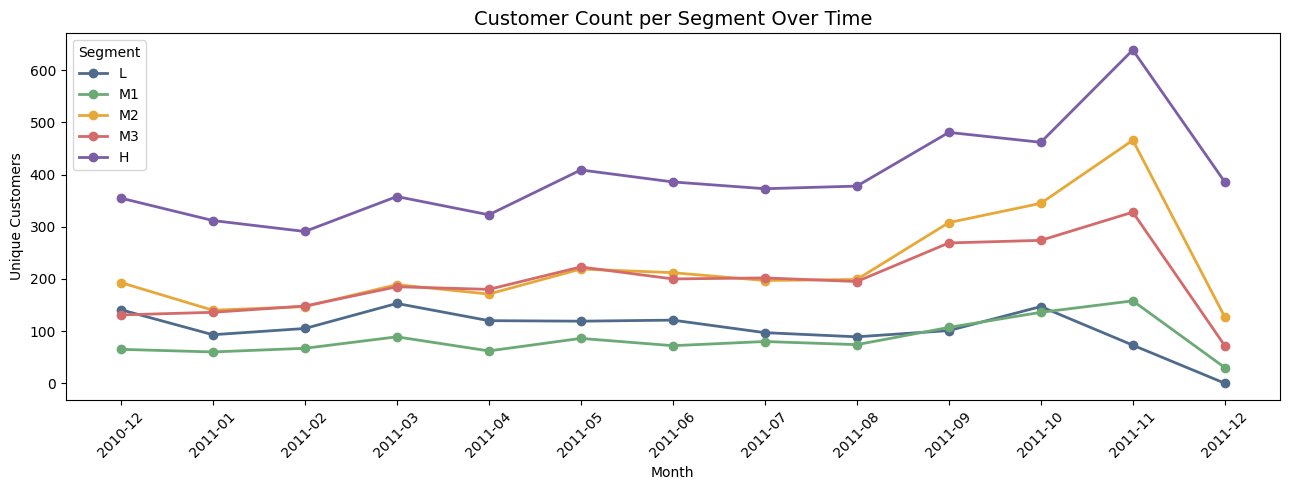

In [60]:
# Customer count per segment per month
monthly_segment_customers = (
    df_segmented
    .groupby(['YearMonth', 'Extended_Segment'], observed=False)['CustomerID']
    .nunique()
    .unstack()
    .reindex(columns=SEGMENT_ORDER, fill_value=0)
)
monthly_segment_customers.index = monthly_segment_customers.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
for seg in SEGMENT_ORDER:
    ax.plot(monthly_segment_customers.index, monthly_segment_customers[seg],
            marker='o', label=seg, color=PALETTE[seg], linewidth=2)
ax.set_title('Customer Count per Segment Over Time', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Unique Customers')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Segment')
plt.tight_layout()
plt.show()

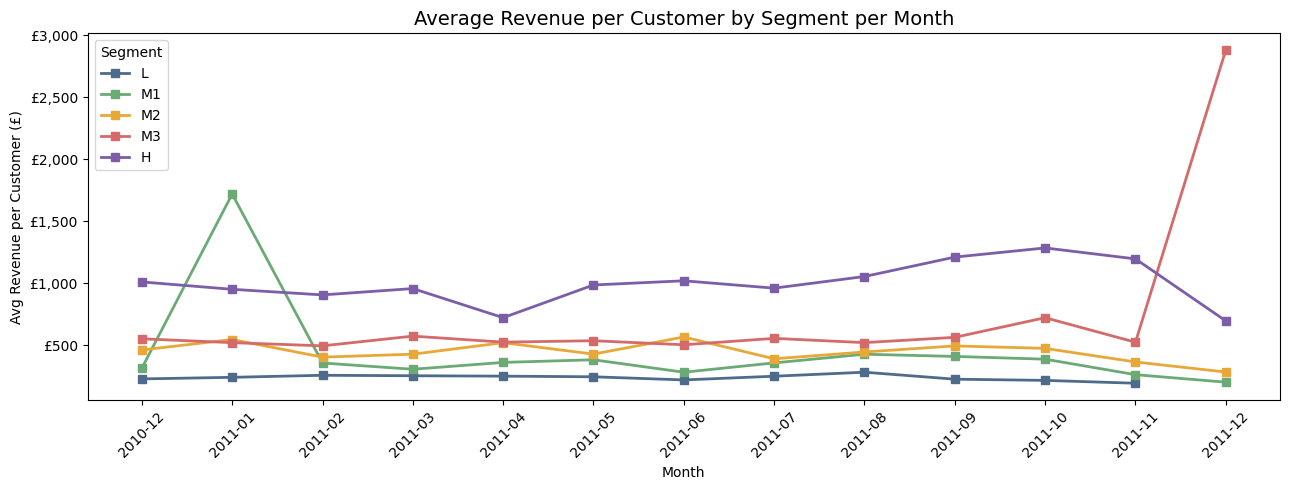

In [61]:
# Average revenue per customer by segment per month
avg_rev_per_customer = monthly_segment_revenue / monthly_segment_customers.replace(0, np.nan)

fig, ax = plt.subplots(figsize=(13, 5))
for seg in SEGMENT_ORDER:
    ax.plot(avg_rev_per_customer.index, avg_rev_per_customer[seg],
            marker='s', label=seg, color=PALETTE[seg], linewidth=2)
ax.set_title('Average Revenue per Customer by Segment per Month', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Avg Revenue per Customer (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Segment')
plt.tight_layout()
plt.show()

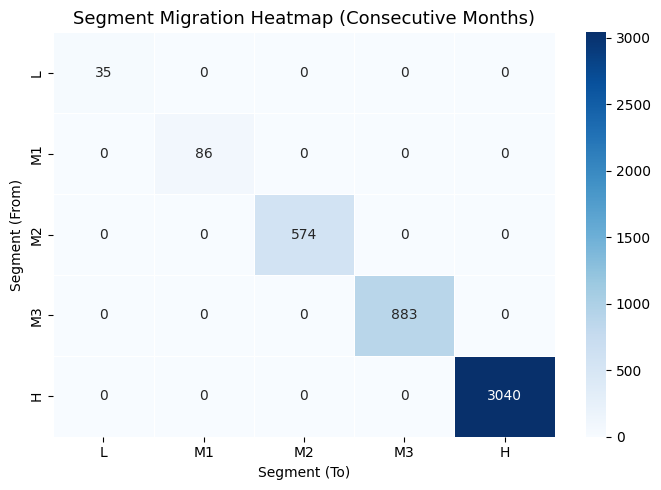

In [62]:
# Segment migration heatmap (consecutive months)
months = monthly_segment_customers.index.tolist()
migration_matrix = pd.DataFrame(0, index=SEGMENT_ORDER, columns=SEGMENT_ORDER, dtype=float)

for i in range(len(months) - 1):
    m_from, m_to = months[i], months[i + 1]
    cust_from = df_segmented[df_segmented['YearMonth'].astype(str) == m_from][['CustomerID', 'Extended_Segment']].drop_duplicates()
    cust_to   = df_segmented[df_segmented['YearMonth'].astype(str) == m_to][['CustomerID', 'Extended_Segment']].drop_duplicates()
    merged = cust_from.merge(cust_to, on='CustomerID', suffixes=('_from', '_to'))
    for _, row in merged.iterrows():
        seg_f = str(row['Extended_Segment_from'])
        seg_t = str(row['Extended_Segment_to'])
        if seg_f in SEGMENT_ORDER and seg_t in SEGMENT_ORDER:
            migration_matrix.loc[seg_f, seg_t] += 1

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(migration_matrix.astype(int), annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_title('Segment Migration Heatmap (Consecutive Months)', fontsize=13)
ax.set_xlabel('Segment (To)')
ax.set_ylabel('Segment (From)')
plt.tight_layout()
plt.show()

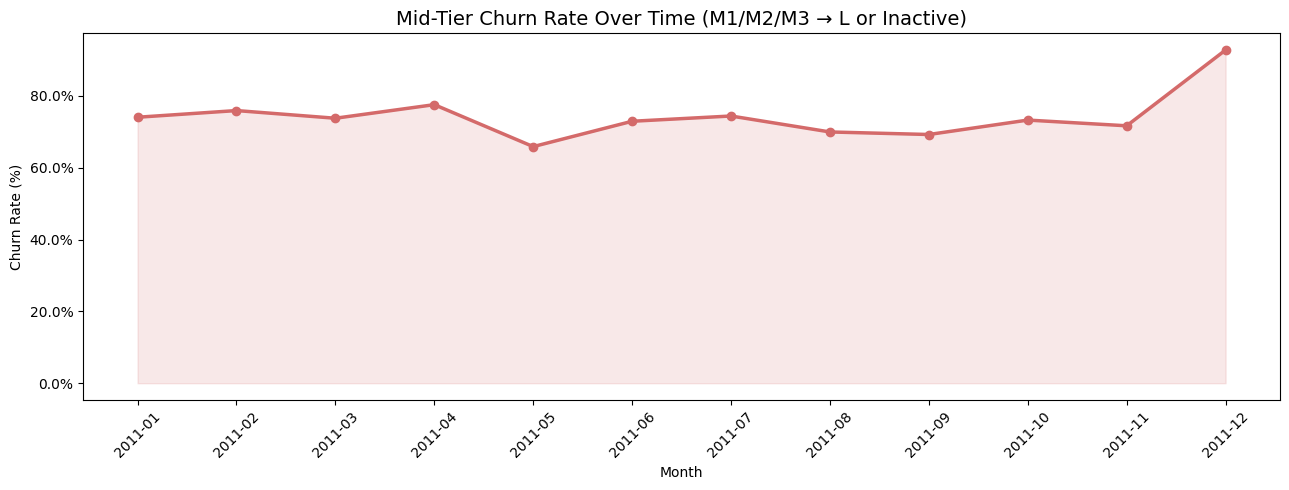

In [63]:
# Mid-tier churn rate over time (M1/M2/M3 → L or disappeared next month)
MID_TIERS = ['M1', 'M2', 'M3']
churn_rates = []

for i in range(len(months) - 1):
    m_from, m_to = months[i], months[i + 1]
    mid_from = df_segmented[
        (df_segmented['YearMonth'].astype(str) == m_from) &
        (df_segmented['Extended_Segment'].isin(MID_TIERS))
    ][['CustomerID', 'Extended_Segment']].drop_duplicates()

    active_next = df_segmented[
        df_segmented['YearMonth'].astype(str) == m_to
    ][['CustomerID', 'Extended_Segment']].drop_duplicates()

    merged = mid_from.merge(active_next, on='CustomerID', suffixes=('_from', '_to'), how='left')
    churned = merged[
        merged['Extended_Segment_to'].isna() |
        (merged['Extended_Segment_to'] == 'L')
    ]
    rate = len(churned) / len(mid_from) * 100 if len(mid_from) > 0 else 0
    churn_rates.append({'Month': m_to, 'ChurnRate': rate})

churn_df = pd.DataFrame(churn_rates)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(churn_df['Month'], churn_df['ChurnRate'], marker='o', color='#D46A6A', linewidth=2.5)
ax.fill_between(churn_df['Month'], churn_df['ChurnRate'], alpha=0.15, color='#D46A6A')
ax.set_title('Mid-Tier Churn Rate Over Time (M1/M2/M3 → L or Inactive)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Churn Rate (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

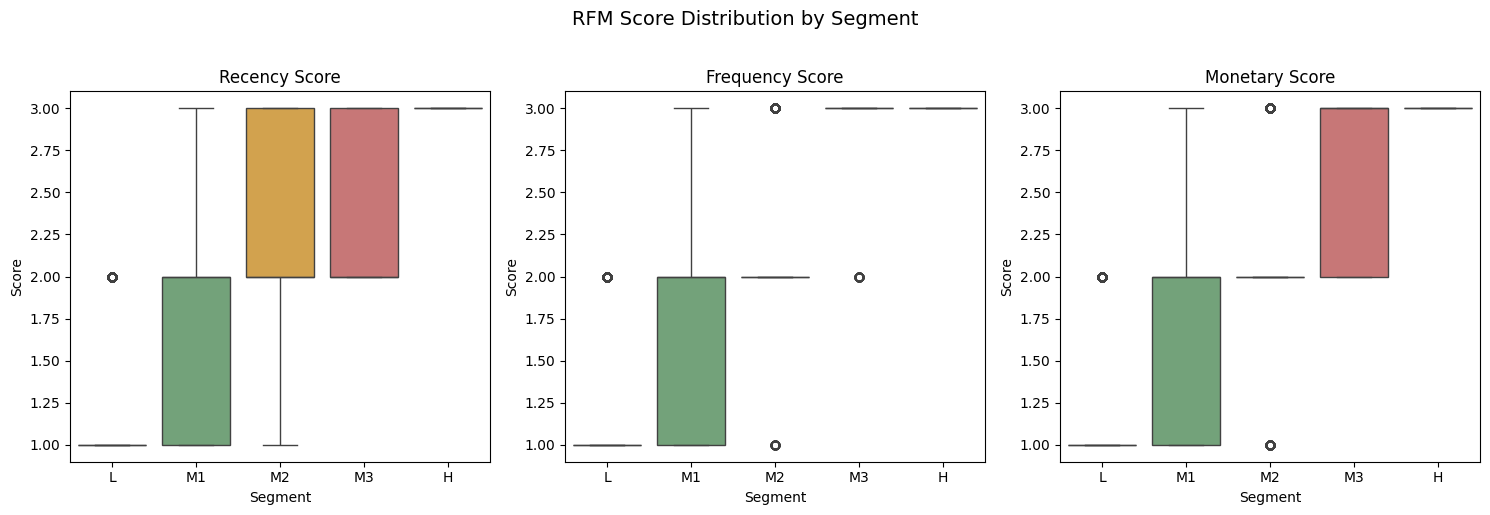

In [64]:
# RFM score distribution by segment — box plots for R, F, M
rfm_plot = rfm[['R_score', 'F_score', 'M_score', 'Extended_Segment']].copy()
rfm_plot[['R_score', 'F_score', 'M_score']] = rfm_plot[['R_score', 'F_score', 'M_score']].astype(float)
rfm_plot['Extended_Segment'] = rfm_plot['Extended_Segment'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, score, label in zip(axes, ['R_score', 'F_score', 'M_score'], ['Recency Score', 'Frequency Score', 'Monetary Score']):
    sns.boxplot(
        data=rfm_plot,
        x='Extended_Segment', y=score,
        order=SEGMENT_ORDER,
        palette=PALETTE,
        ax=ax,
        hue='Extended_Segment',
        legend=False
    )
    ax.set_title(label)
    ax.set_xlabel('Segment')
    ax.set_ylabel('Score')

fig.suptitle('RFM Score Distribution by Segment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

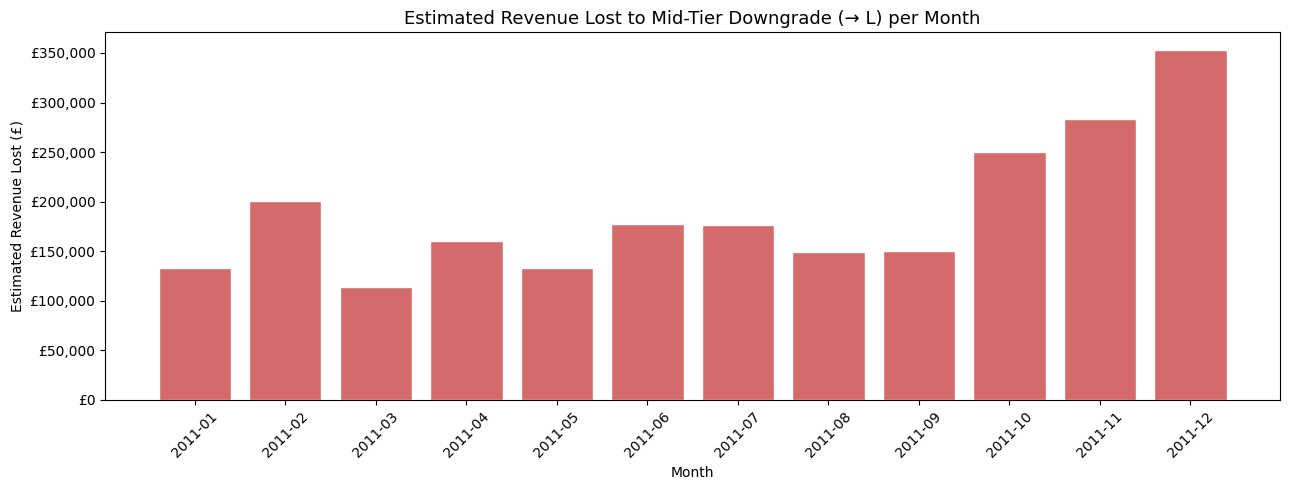

In [65]:
# Revenue lost to downgrade (mid-tier → L per month)
MID_TIERS = ['M1', 'M2', 'M3']
revenue_lost_list = []

for i in range(len(months) - 1):
    m_from, m_to = months[i], months[i + 1]

    mid_from = df_segmented[
        (df_segmented['YearMonth'].astype(str) == m_from) &
        (df_segmented['Extended_Segment'].isin(MID_TIERS))
    ][['CustomerID', 'Extended_Segment', 'TotalPrice']]

    avg_rev = mid_from.groupby(['CustomerID', 'Extended_Segment'])['TotalPrice'].sum().reset_index()
    avg_rev_by_seg = avg_rev.groupby('Extended_Segment')['TotalPrice'].mean().to_dict()

    active_next = df_segmented[
        df_segmented['YearMonth'].astype(str) == m_to
    ][['CustomerID', 'Extended_Segment']].drop_duplicates()

    mid_ids = mid_from[['CustomerID', 'Extended_Segment']].drop_duplicates()
    merged = mid_ids.merge(active_next, on='CustomerID', suffixes=('_from', '_to'), how='left')
    downgraded = merged[
        merged['Extended_Segment_to'].isna() |
        (merged['Extended_Segment_to'] == 'L')
    ]

    lost = sum(
        avg_rev_by_seg.get(str(row['Extended_Segment_from']), 0)
        for _, row in downgraded.iterrows()
    )
    revenue_lost_list.append({'Month': m_to, 'RevenueLost': lost})

revenue_lost_df = pd.DataFrame(revenue_lost_list)

revenue_lost_df.to_csv('tableau_revenue_lost.csv', index=False)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(revenue_lost_df['Month'], revenue_lost_df['RevenueLost'], color='#D46A6A', edgecolor='white')
ax.set_title('Estimated Revenue Lost to Mid-Tier Downgrade (→ L) per Month', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Estimated Revenue Lost (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

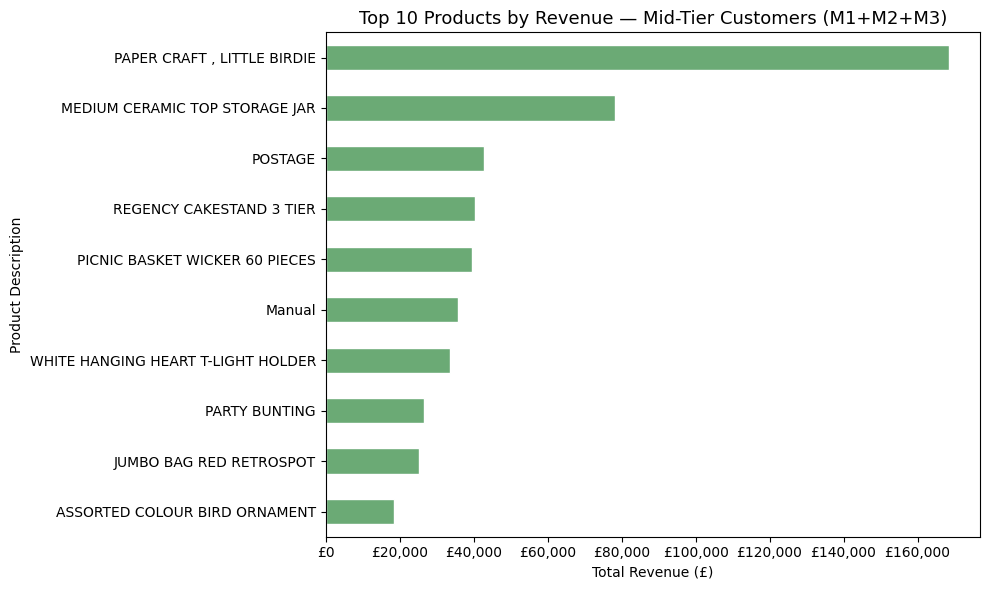

In [66]:
# Top 10 products preferred by mid-tier customers (M1+M2+M3)
mid_tier_txns = df_segmented[df_segmented['Extended_Segment'].isin(['M1', 'M2', 'M3'])]
top_products = (
    mid_tier_txns.groupby('Description')['TotalPrice']
    .sum()
    .nlargest(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
top_products.plot(kind='barh', ax=ax, color='#6BAA75', edgecolor='white')
ax.set_title('Top 10 Products by Revenue — Mid-Tier Customers (M1+M2+M3)', fontsize=13)
ax.set_xlabel('Total Revenue (£)')
ax.set_ylabel('Product Description')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

## Business Conclusion: The Real Cost of Mid-Tier Neglect

### Revenue Summary

> The following figures are computed in the code cell below.

### Strategic Recommendations

1. **Systematic Mid-Tier Re-Engagement** 
   Mid-tier customers (M1, M2, M3) collectively represent a substantial share of total revenue, yet their monthly churn rate is consistently higher than the high-value H segment. A recurring monthly re-engagement campaign — timed around natural seasonal triggers (Valentine's, Easter, Summer, Pre-Christmas) — would reduce churn and stabilize mid-tier revenue.

2. **Graduated Loyalty Incentives** 
   Rather than treating all mid-tier uniformly, deploy a tiered loyalty structure: M1 customers receive entry rewards, M2 receive mid-tier perks, and M3 receive near-VIP access. This reduces downward migration from M3→M2→M1→L and motivates upward movement into the H tier — which has the highest revenue per customer.

3. **Product-Anchored Retention** 
   The top products analysis reveals that mid-tier customers purchase specific high-value home goods and accessories. Targeted campaigns built around these products — personalized restocking alerts, seasonal bundles, and cross-sell recommendations — will increase purchase frequency and monetary value, improving RFM scores and naturally elevating customers from M1/M2 toward M3/H.

In [67]:
# Business summary table: total revenue, avg monthly revenue, peak month, churn rate per segment
total_revenue_by_seg = monthly_segment_revenue.sum()
avg_monthly_by_seg   = monthly_segment_revenue.mean()
peak_month_by_seg    = monthly_segment_revenue.idxmax()

# Compute average churn rate per mid-tier segment
churn_by_seg = {seg: [] for seg in SEGMENT_ORDER}
for i in range(len(months) - 1):
    m_from, m_to = months[i], months[i + 1]
    for seg in SEGMENT_ORDER:
        seg_from = df_segmented[
            (df_segmented['YearMonth'].astype(str) == m_from) &
            (df_segmented['Extended_Segment'] == seg)
        ]['CustomerID'].unique()
        if len(seg_from) == 0:
            continue
        seg_to = df_segmented[
            df_segmented['YearMonth'].astype(str) == m_to
        ].groupby('CustomerID')['Extended_Segment'].first().to_dict()
        churned_count = sum(
            1 for cid in seg_from
            if cid not in seg_to or seg_to[cid] == 'L'
        )
        churn_by_seg[seg].append(churned_count / len(seg_from) * 100)

avg_churn_by_seg = {seg: (np.mean(v) if v else 0.0) for seg, v in churn_by_seg.items()}

# Build summary DataFrame
total_rev_all = total_revenue_by_seg.sum()
summary_df = pd.DataFrame({
    'Total Revenue (£)':     total_revenue_by_seg.map(lambda x: f'£{x:,.0f}'),
    'Avg Monthly Revenue (£)': avg_monthly_by_seg.map(lambda x: f'£{x:,.0f}'),
    'Peak Month':            peak_month_by_seg,
    'Avg Churn Rate (%)':    pd.Series(avg_churn_by_seg).map(lambda x: f'{x:.1f}%'),
    '% of Total Revenue':   (total_revenue_by_seg / total_rev_all * 100).map(lambda x: f'{x:.1f}%')
})
summary_df.index.name = 'Segment'

mid_rev  = total_revenue_by_seg[['M1', 'M2', 'M3']].sum()
total_rev_lost = revenue_lost_df['RevenueLost'].sum()

print(f"Total revenue from M1+M2+M3:          £{mid_rev:,.0f}")
print(f"Total estimated revenue lost (churn):  £{total_rev_lost:,.0f}")
print(f"Mid-tier % of total revenue:           {mid_rev / total_rev_all * 100:.1f}%")
print()
display(summary_df)

Total revenue from M1+M2+M3:          £3,330,363
Total estimated revenue lost (churn):  £2,280,872
Mid-tier % of total revenue:           37.4%



,Total Revenue (£),Avg Monthly Revenue (£),Peak Month,Avg Churn Rate (%),% of Total Revenue
Segment,,,,,
L,"£324,578","£24,968",2011-03,100.0%,3.6%
M1,"£454,611","£34,970",2011-01,90.6%,5.1%
M2,"£1,296,242","£99,711",2011-11,78.3%,14.5%
M3,"£1,579,509","£121,501",2011-12,63.2%,17.7%
H,"£5,256,467","£404,344",2011-11,35.8%,59.0%
